# Monsoon Onset & Soil Moisture — Core Monsoon Zone (CMZ) Composite Analysis — 2025

Composite analysis of ERA5 surface soil moisture response to monsoon onset, **restricted to grid points within the Core Monsoon Zone (CMZ)**.

**Workflow:**
1. Load remapped ERA5 `swvl1` (already on IMD 1° grid) and IMD rainfall
2. Define the CMZ polygon and build a 2-D boolean mask
3. Detect monsoon onset dates (IMD-based algorithm)
4. Extract ±30-day soil moisture composites — **CMZ grid points only**
5. Compute domain-mean total soil moisture profile + rainfall (right axis)
6. Plot spatial maps of SM at onset and lag = +7 days (CMZ highlighted)

## 1. Import Required Libraries

In [9]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath(".."))

import yaml
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as mgridspec
from matplotlib.colors import BoundaryNorm
from matplotlib.path import Path

# Package utilities
import monsoon_onset.detector as _det
import monsoon_onset.loader   as _ldr
import monsoon_onset.plotter  as _plt
importlib.reload(_det); importlib.reload(_ldr); importlib.reload(_plt)

from monsoon_onset.loader   import load_rainfall
from monsoon_onset.detector import detect_onset
from monsoon_onset.plotter  import get_india_outline, doy_to_date_string

%matplotlib inline
os.makedirs("../output", exist_ok=True)
print("All imports OK")

All imports OK


## 2. Load Remapped ERA5 Soil Moisture and IMD Rainfall

Load the CDO-remapped ERA5 `swvl1` file (already on the IMD 1° grid) and the IMD daily rainfall for 2025.

In [10]:
YEAR = 2025

# ── Load config ───────────────────────────────────────────────────────────────
with open("../configs/imd_1deg.yaml") as f:
    cfg = yaml.safe_load(f)
dataset_cfg = cfg["dataset"]
onset_cfg   = cfg["onset"]
shp_path    = dataset_cfg.get("shapefile")

# ── Paths ─────────────────────────────────────────────────────────────────────
SM_FILE       = f"../data/era5_swvl1_{YEAR}.nc"
sm_remap_file = SM_FILE.replace(".nc", "_remapcon_imd1deg.nc")

# ── Load remapped ERA5 soil moisture ─────────────────────────────────────────
sm_ds  = xr.open_dataset(sm_remap_file)
sm_var = [v for v in sm_ds.data_vars if "swvl" in v.lower() or "soil" in v.lower()][0]
sm_imd = sm_ds[sm_var]

# Standardise dimension names → 'lat' / 'lon'
_LAT_NAMES = {"latitude", "lat", "LATITUDE", "LAT", "nav_lat"}
_LON_NAMES = {"longitude", "lon", "LONGITUDE", "LON", "nav_lon"}
rename = {}
for d in sm_imd.dims:
    if d in _LAT_NAMES and d != "lat":
        rename[d] = "lat"
    if d in _LON_NAMES and d != "lon":
        rename[d] = "lon"
if rename:
    sm_imd = sm_imd.rename(rename)
    print(f"Renamed dims: {rename}")

sm_imd["time"] = pd.to_datetime(sm_imd.time.values)
sm_imd.name = "swvl1"
sm_imd.attrs["units"] = "m3 m-3"

target_lat = sm_imd.lat.values
target_lon = sm_imd.lon.values

# ── Load IMD rainfall ─────────────────────────────────────────────────────────
rainfall_da = load_rainfall(YEAR, dataset_cfg)

print(f"SM file         : {sm_remap_file}")
print(f"SM variable     : {sm_var}")
print(f"Grid            : {len(target_lat)} lats × {len(target_lon)} lons")
print(f"Lat range       : {float(sm_imd.lat.min()):.1f} – {float(sm_imd.lat.max()):.1f} °N")
print(f"Lon range       : {float(sm_imd.lon.min()):.1f} – {float(sm_imd.lon.max()):.1f} °E")
print(f"SM value range  : {float(sm_imd.min()):.4f} – {float(sm_imd.max()):.4f}  m³/m³")
print(f"Rainfall shape  : {rainfall_da.shape}")
sm_imd

Renamed dims: {'LATITUDE': 'lat', 'LONGITUDE': 'lon'}
Loading 2025 rainfall from: /Users/Rajat/Library/CloudStorage/OneDrive-TheUniversityofChicago/documents/conferences/icts_monsoon_26/mr_onset/data/imd/data_2025.nc
Renamed dimensions: {'LONGITUDE': 'lon', 'LATITUDE': 'lat', 'TIME': 'time'}
SM file         : ../data/era5_swvl1_2025_remapcon_imd1deg.nc
SM variable     : volumetric_soil_water_layer_1
Grid            : 33 lats × 35 lons
Lat range       : 6.5 – 38.5 °N
Lon range       : 66.5 – 100.5 °E
SM value range  : -0.0014 – 0.6469  m³/m³
Rainfall shape  : (365, 33, 35)


<xarray.DataArray 'swvl1' (time: 183, lat: 33, lon: 35)> Size: 845kB
array([[[-1.080334e-07, -1.080334e-07, ...,  3.060634e-02,  1.258068e-01],
        [-1.080334e-07, -1.080334e-07, ...,  2.172439e-01,  3.412006e-01],
        ...,
        [ 1.716290e-01,  1.958296e-01, ...,  3.014499e-01,  2.453100e-01],
        [ 2.835325e-01,  2.838431e-01, ...,  3.522160e-01,  3.516983e-01]],

       [[-1.825392e-07, -1.825392e-07, ...,  3.564272e-02,  1.419474e-01],
        [-1.825392e-07, -1.825392e-07, ...,  2.508686e-01,  4.255238e-01],
        ...,
        [ 1.429416e-01,  1.729312e-01, ...,  3.000894e-01,  2.449763e-01],
        [ 2.691559e-01,  2.671421e-01, ...,  3.518533e-01,  3.514211e-01]],

       ...,

       [[ 6.373972e-06,  6.373972e-06, ...,  5.279936e-02,  1.796686e-01],
        [ 6.373972e-06,  6.373972e-06, ...,  3.273605e-01,  4.699573e-01],
        ...,
        [ 7.487904e-02,  9.973643e-02, ...,  2.964682e-01,  2.763912e-01],
        [ 1.272314e-01,  1.160648e-01, ...,  3.473899e-01,  3.677543e-01]],

       [[-2.744297e-07, -2.744297e-07, ...,  4.950958e-02,  1.703627e-01],
        [-2.744297e-07, -2.744297e-07, ...,  3.129510e-01,  4.416348e-01],
        ...,
        [ 7.391349e-02,  9.843095e-02, ...,  2.897996e-01,  2.697315e-01],
        [ 1.248906e-01,  1.133764e-01, ...,  3.417542e-01,  3.630550e-01]]],
      shape=(183, 33, 35), dtype=float32)
Coordinates:
  * lon      (lon) float64 280B 66.5 67.5 68.5 69.5 ... 97.5 98.5 99.5 100.5
  * lat      (lat) float64 264B 6.5 7.5 8.5 9.5 10.5 ... 35.5 36.5 37.5 38.5
  * time     (time) datetime64[ns] 1kB 2025-04-01 2025-04-02 ... 2025-09-30
Attributes:
    long_name:   Volumetric soil water layer 1
    units:       m3 m-3
    short_name:  swvl1

## 3. Define Core Monsoon Zone (CMZ) Mask

The CMZ polygon (Rajeevan et al. 2010) covers central India (roughly 18–28°N, 69–88°E).  
Grid-cell centres that fall inside the polygon are flagged as `True`.

CMZ grid points : 141
Loaded India outline from: /Users/Rajat/Library/CloudStorage/OneDrive-TheUniversityofChicago/documents/conferences/icts_monsoon_26/mr_onset/data/ind_map_shpfile/india_shapefile.shp


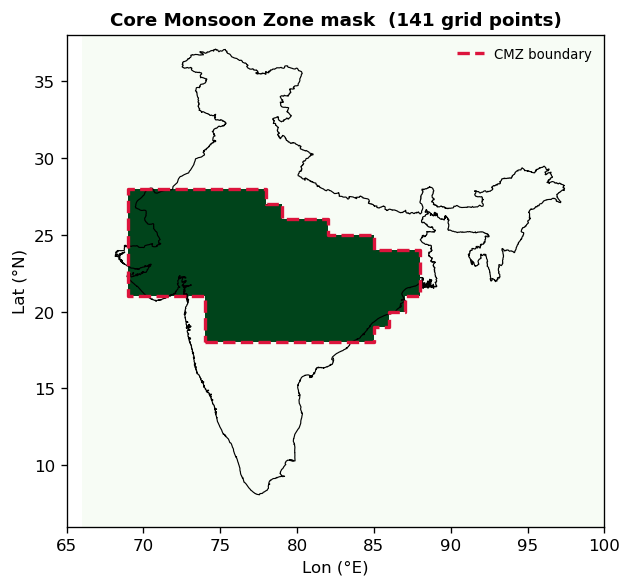

In [11]:
# ── CMZ polygon vertices (Rajeevan et al. 2010) ──────────────────────────────
cmz_lon = np.array([74, 85, 85, 86, 86, 87, 87, 88, 88, 88, 85, 85, 82, 82, 79, 79, 78, 78, 69, 69, 74, 74])
cmz_lat = np.array([18, 18, 19, 19, 20, 20, 21, 21, 21, 24, 24, 25, 25, 26, 26, 27, 27, 28, 28, 21, 21, 18])
cmz_path = Path(np.column_stack([cmz_lon, cmz_lat]))

# ── Build 2-D boolean mask on the IMD 1° grid ─────────────────────────────────
LON_c, LAT_c = np.meshgrid(target_lon, target_lat)
pts = np.column_stack([LON_c.ravel(), LAT_c.ravel()])
cmz_mask_2d = cmz_path.contains_points(pts).reshape(LON_c.shape)   # [lat, lon]

cmz_mask_da = xr.DataArray(
    cmz_mask_2d, dims=["lat", "lon"],
    coords={"lat": target_lat, "lon": target_lon},
)

n_cmz = int(cmz_mask_2d.sum())
print(f"CMZ grid points : {n_cmz}")

# ── Quick preview map ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5), dpi=120)
ax.pcolormesh(target_lon, target_lat, cmz_mask_2d.astype(float),
              cmap="Greens", vmin=0, vmax=1, shading="nearest")
for lons_b, lats_b in get_india_outline(shapefile_path=shp_path):
    ax.plot(lons_b, lats_b, color="black", linewidth=0.7)
ax.plot(np.append(cmz_lon, cmz_lon[0]), np.append(cmz_lat, cmz_lat[0]),
        color="crimson", linewidth=2, linestyle="--", label="CMZ boundary")
ax.set_xlim(65, 100); ax.set_ylim(6, 38)
ax.set_aspect("equal", adjustable="box")
ax.set_title(f"Core Monsoon Zone mask  ({n_cmz} grid points)", fontsize=11, fontweight="bold")
ax.set_xlabel("Lon (°E)"); ax.set_ylabel("Lat (°N)")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

## 4. Compute Monsoon Onset Dates for 2025

Run the IMD-based onset detection algorithm on the full domain, then mask to CMZ.

In [12]:
thresh_ds = xr.open_dataset(dataset_cfg["threshold_file"])
thresh_da = thresh_ds[dataset_cfg.get("threshold_var", "MWmean")]

onset_da = detect_onset(
    rainfall_da=rainfall_da,
    threshold_da=thresh_da,
    year=YEAR,
    cfg=onset_cfg,
)

# DOY version (full domain)
onset_doy = xr.where(onset_da.notnull(), onset_da.dt.dayofyear.astype(float), np.nan)

# ── Apply CMZ mask ────────────────────────────────────────────────────────────
onset_cmz     = onset_da.where(cmz_mask_da)
onset_doy_cmz = xr.where(onset_cmz.notnull(), onset_cmz.dt.dayofyear.astype(float), np.nan)

valid_cmz = int(onset_doy_cmz.notnull().sum())
total_cmz = int(cmz_mask_2d.sum())
print(f"CMZ grid points with valid onset : {valid_cmz} / {total_cmz}")
print(f"CMZ earliest onset : {doy_to_date_string(float(onset_doy_cmz.min()))}")
print(f"CMZ latest   onset : {doy_to_date_string(float(onset_doy_cmz.max()))}")
mean_doy = float(onset_doy_cmz.mean())
print(f"CMZ mean     onset : {doy_to_date_string(mean_doy)}  (DOY {mean_doy:.1f})")
onset_cmz

Onset detection start: 2025-04-01
  Valid onsets: 326/1155 (28.2%)
CMZ grid points with valid onset : 134 / 141
CMZ earliest onset : 04/13
CMZ latest   onset : 08/16
CMZ mean     onset : 06/10  (DOY 161.4)


<xarray.DataArray 'onset_date' (lat: 33, lon: 35)> Size: 9kB
array([['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ...,
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT']],
      shape=(33, 35), dtype='datetime64[ns]')
Coordinates:
  * lat      (lat) float64 264B 6.5 7.5 8.5 9.5 10.5 ... 35.5 36.5 37.5 38.5
  * lon      (lon) float64 280B 66.5 67.5 68.5 69.5 ... 97.5 98.5 99.5 100.5
Attributes:
    description:           Onset date with dry-spell veto
    start_date:            2025-04-01
    wet_spell_window:      5
    dry_spell_window:      10
    dry_spell_threshold:   5
    dry_spell_check_days:  30
    mok_filter:            False

## 5. Extract Soil Moisture & Rainfall Time-series Centred on Onset

Two extractions are done here:
- **CMZ only** (`sm_centred_da`, `rain_centred_da`) — used for the domain-mean time-series composites
- **Full domain** (`sm_centred_full_da`) — used for spatial maps so the whole India domain is shown

For each grid point with a valid onset date, soil moisture is extracted for a **±30-day window** around the onset date (`lag = 0`).

In [13]:
HALF_WIN = 30
lags     = np.arange(-HALF_WIN, HALF_WIN + 1)   # -30 … +30

sm_vals    = sm_imd.values            # [time, lat, lon]
rain_vals  = rainfall_da.values       # [time, lat, lon]
time_idx   = pd.DatetimeIndex(sm_imd.time.values)
rain_times = pd.DatetimeIndex(rainfall_da.time.values)

n_lat = len(target_lat)
n_lon = len(target_lon)
n_lag = len(lags)

# ── CMZ-only arrays (for time-series composites) ──────────────────────────────
sm_centred   = np.full((n_lag, n_lat, n_lon), np.nan)
rain_centred = np.full((n_lag, n_lat, n_lon), np.nan)

# ── Full-domain array (for spatial maps) ─────────────────────────────────────
sm_centred_full = np.full((n_lag, n_lat, n_lon), np.nan)

for i, lat_v in enumerate(target_lat):
    for j, lon_v in enumerate(target_lon):
        onset_ts = onset_da.sel(lat=lat_v, lon=lon_v).values
        if pd.isna(onset_ts):
            continue
        onset_date = pd.Timestamp(onset_ts)

        for k, lag in enumerate(lags):
            tgt = onset_date + pd.Timedelta(days=int(lag))
            # ── Full-domain SM (all valid grid points) ────────────────────────
            if tgt in time_idx:
                sm_centred_full[k, i, j] = sm_vals[time_idx.get_loc(tgt), i, j]
            # ── CMZ-only (skip points outside CMZ) ────────────────────────────
            if cmz_mask_2d[i, j]:
                if tgt in time_idx:
                    sm_centred[k, i, j]   = sm_vals[time_idx.get_loc(tgt), i, j]
                if tgt in rain_times:
                    rain_centred[k, i, j] = rain_vals[rain_times.get_loc(tgt), i, j]

# ── CMZ xarray DataArrays ─────────────────────────────────────────────────────
sm_centred_da = xr.DataArray(
    sm_centred,
    dims=["lag", "lat", "lon"],
    coords={"lag": lags, "lat": target_lat, "lon": target_lon},
    name="swvl1_onset_centred_cmz",
    attrs={"units": "m3 m-3",
           "description": f"SM ±{HALF_WIN} days around onset — CMZ grid points only"},
)

rain_centred_da = xr.DataArray(
    rain_centred,
    dims=["lag", "lat", "lon"],
    coords={"lag": lags, "lat": target_lat, "lon": target_lon},
    name="rain_onset_centred_cmz",
    attrs={"units": "mm/day",
           "description": f"Rainfall ±{HALF_WIN} days around onset — CMZ grid points only"},
)

# ── Full-domain xarray DataArray (for spatial maps) ───────────────────────────
sm_centred_full_da = xr.DataArray(
    sm_centred_full,
    dims=["lag", "lat", "lon"],
    coords={"lag": lags, "lat": target_lat, "lon": target_lon},
    name="swvl1_onset_centred_full",
    attrs={"units": "m3 m-3",
           "description": f"SM ±{HALF_WIN} days around onset — full domain"},
)

valid_cmz_pts  = int(np.isfinite(sm_centred[HALF_WIN]).sum())
valid_full_pts = int(np.isfinite(sm_centred_full[HALF_WIN]).sum())
print(f"CMZ  grid points with SM at onset (lag=0): {valid_cmz_pts}")
print(f"Full grid points with SM at onset (lag=0): {valid_full_pts}")
sm_centred_da

CMZ  grid points with SM at onset (lag=0): 134
Full grid points with SM at onset (lag=0): 325


<xarray.DataArray 'swvl1_onset_centred_cmz' (lag: 61, lat: 33, lon: 35)> Size: 564kB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(61, 33, 35))
Coordinates:
  * lag      (lag) int64 488B -30 -29 -28 -27 -26 -25 -24 ... 25 26 27 28 29 30
  * lat      (lat) float64 264B 6.5 7.5 8.5 9.5 10.5 ... 35.5 36.5 37.5 38.5
  * lon      (lon) float64 280B 66.5 67.5 68.5 69.5 ... 97.5 98.5 99.5 100.5
Attributes:
    units:        m3 m-3
    description:  SM ±30 days around onset — CMZ grid points only

## 6. Composite Analysis: Domain-mean Soil Moisture (CMZ)

Compute the CMZ domain-mean soil moisture profile and inter-quartile range across all valid CMZ grid points, centred on onset.

In [36]:
# ── Mask non-CMZ points (set to NaN) before averaging ────────────────────────
# sm_centred_da already has NaN outside CMZ; mean/quantile skip NaN by default

sm_median = sm_centred_da.median(dim=["lat", "lon"])
sm_mean   = sm_centred_da.mean(dim=["lat", "lon"])
sm_p25    = sm_centred_da.quantile(0.25, dim=["lat", "lon"])
sm_p75    = sm_centred_da.quantile(0.75, dim=["lat", "lon"])

rain_median = rain_centred_da.median(dim=["lat", "lon"])
rain_mean   = rain_centred_da.mean(dim=["lat", "lon"])
rain_p25    = rain_centred_da.quantile(0.25, dim=["lat", "lon"])
rain_p75    = rain_centred_da.quantile(0.75, dim=["lat", "lon"])

# ── Quick stats ───────────────────────────────────────────────────────────────
pre_sm   = float(sm_centred_da.sel(lag=slice(-30, -5)).median())
onset_sm = float(sm_centred_da.sel(lag=0).median())
post_sm  = float(sm_centred_da.sel(lag=slice(5, 30)).median())
step     = post_sm - pre_sm

print(f"CMZ median SM  pre-onset  (lag −30 to −5) : {pre_sm:.4f}  m³/m³")
print(f"CMZ median SM  at onset   (lag = 0)        : {onset_sm:.4f}  m³/m³")
print(f"CMZ median SM  post-onset (lag +5 to +30)  : {post_sm:.4f}  m³/m³")
print(f"Step change (post − pre)                    : {step:+.4f}  m³/m³")
print(f"CMZ median rain at onset (lag=0)            : {float(rain_centred_da.sel(lag=0).median(skipna=True)):.2f}  mm/day")

CMZ median SM  pre-onset  (lag −30 to −5) : 0.2056  m³/m³
CMZ median SM  at onset   (lag = 0)        : 0.2945  m³/m³
CMZ median SM  post-onset (lag +5 to +30)  : 0.4075  m³/m³
Step change (post − pre)                    : +0.2019  m³/m³
CMZ median rain at onset (lag=0)            : 9.45  mm/day


## 7. Visualise Soil Moisture Pick-up Around Onset (CMZ)

Three panels:
- **A** — CMZ domain-mean SM time-series (±30 days, IQR shading) with rainfall on right axis
- **B** — Spatial map of SM at onset (`lag = 0`), CMZ boundary overlaid
- **C** — Spatial map of SM at `lag = +7` days

Colorbar range : 0.038 – 0.483  m³/m³  (16 levels)
Loaded India outline from: /Users/Rajat/Library/CloudStorage/OneDrive-TheUniversityofChicago/documents/conferences/icts_monsoon_26/mr_onset/data/ind_map_shpfile/india_shapefile.shp
Loaded India outline from: /Users/Rajat/Library/CloudStorage/OneDrive-TheUniversityofChicago/documents/conferences/icts_monsoon_26/mr_onset/data/ind_map_shpfile/india_shapefile.shp


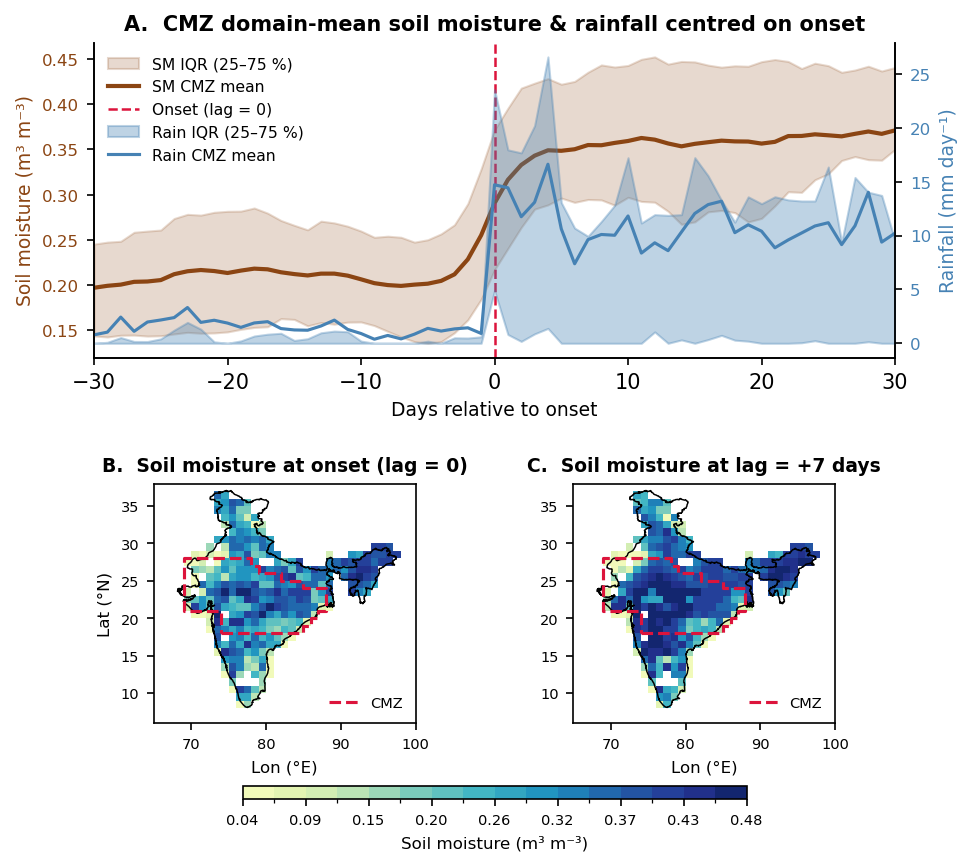

Figure saved → ../output/sm_onset_cmz_2025.png


In [37]:
fig = plt.figure(figsize=(6, 6), dpi=150)
gs  = mgridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.1,
                          left=0.07, right=0.96, top=0.92, bottom=0.08)

map_extent = [65, 100, 6, 38]
rain_color = "steelblue"
rain_alpha = 0.35
sm_color   = "saddlebrown"

# ── Slices that will be plotted ───────────────────────────────────────────────
sm_at_onset = sm_centred_full_da.sel(lag=0).values
sm_lag7     = sm_centred_full_da.sel(lag=7).values

# ── Shared colormap: range from the two plotted slices only ──────────────────
vals_plot = np.concatenate([
    sm_at_onset[np.isfinite(sm_at_onset)].ravel(),
    sm_lag7[np.isfinite(sm_lag7)].ravel(),
])
vmin = max(0.02, np.nanpercentile(vals_plot, 2))
vmax = min(0.55, np.nanpercentile(vals_plot, 98))
n_levels  = 16
sm_bounds = np.linspace(vmin, vmax, n_levels + 1)
sm_cmap   = mcolors.ListedColormap(plt.cm.YlGnBu(np.linspace(0.1, 0.95, n_levels)))
sm_norm   = BoundaryNorm(sm_bounds, n_levels)

print(f"Colorbar range : {vmin:.3f} – {vmax:.3f}  m³/m³  ({n_levels} levels)")

# ── Helper: draw map panel ────────────────────────────────────────────────────
def _map(ax, data, title, draw_cmz=True):
    im = ax.pcolormesh(target_lon, target_lat, data,
                       cmap=sm_cmap, norm=sm_norm, shading="nearest", rasterized=True)
    for lons_b, lats_b in get_india_outline(shapefile_path=shp_path):
        ax.plot(lons_b, lats_b, color="black", linewidth=0.7)
    if draw_cmz:
        ax.plot(np.append(cmz_lon, cmz_lon[0]),
                np.append(cmz_lat, cmz_lat[0]),
                color="crimson", linewidth=1.5, linestyle="--", zorder=10, label="CMZ")
        ax.legend(fontsize=7, frameon=False, loc="lower right")
    ax.patch.set_visible(False)
    ax.set_xlim(map_extent[0], map_extent[1])
    ax.set_ylim(map_extent[2], map_extent[3])
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title, fontsize=9, fontweight="bold")
    ax.set_xlabel("Lon (°E)", fontsize=8)
    ax.tick_params(labelsize=7)
    return im

# ── Panel A: CMZ domain-median SM + rainfall time-series ─────────────────────
axA = fig.add_subplot(gs[0, :])
axA.fill_between(lags, sm_p25.values, sm_p75.values,
                 color=sm_color, alpha=0.20, label="SM IQR (25–75 %)")
axA.plot(lags, sm_mean.values, color=sm_color, linewidth=2.0,
         label="SM CMZ mean")
axA.axvline(0, color="crimson", linewidth=1.2, linestyle="--", label="Onset (lag = 0)")
axA.set_xlabel("Days relative to onset", fontsize=9)
axA.set_ylabel("Soil moisture (m³ m⁻³)", color=sm_color, fontsize=9)
axA.tick_params(axis="y", labelcolor=sm_color, labelsize=8)
axA.set_xlim(lags[0], lags[-1])
axA.set_title("A.  CMZ domain-mean soil moisture & rainfall centred on onset",
              fontsize=10, fontweight="bold")
axA.spines["top"].set_visible(False)

axA_r = axA.twinx()
axA_r.fill_between(lags, rain_p25.values, rain_p75.values,
                   color=rain_color, alpha=rain_alpha, label="Rain IQR (25–75 %)")
axA_r.plot(lags, rain_mean.values, color=rain_color, linewidth=1.5,
           label="Rain CMZ mean")
axA_r.set_ylabel("Rainfall (mm day⁻¹)", color=rain_color, fontsize=9)
axA_r.tick_params(axis="y", labelcolor=rain_color, labelsize=8)
axA_r.spines["top"].set_visible(False)

h1, l1 = axA.get_legend_handles_labels()
h2, l2 = axA_r.get_legend_handles_labels()
axA.legend(h1 + h2, l1 + l2, fontsize=7.5, frameon=False, loc="upper left")

# ── Panel B: SM at onset (lag = 0) ───────────────────────────────────────────
axB = fig.add_subplot(gs[1, 0])
im = _map(axB, sm_at_onset, "B.  Soil moisture at onset (lag = 0)")
axB.set_ylabel("Lat (°N)", fontsize=8)

# ── Panel C: SM at lag = +7 ──────────────────────────────────────────────────
axC = fig.add_subplot(gs[1, 1])
_map(axC, sm_lag7, "C.  Soil moisture at lag = +7 days")

# ── Single shared horizontal colorbar below both map panels ──────────────────
cbar = fig.colorbar(
    im, ax=[axB, axC],
    orientation="horizontal",
    pad=0.2, fraction=0.04, aspect=40,
    ticks=sm_bounds[::2],          # every other tick to avoid crowding
)
cbar.set_label("Soil moisture (m³ m⁻³)", fontsize=8)
cbar.ax.tick_params(labelsize=7)
# format tick labels to 2 decimal places
cbar.ax.set_xticklabels([f"{v:.2f}" for v in sm_bounds[::2]], fontsize=7)

plt.savefig(f"../output/sm_onset_cmz_{YEAR}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → ../output/sm_onset_cmz_{YEAR}.png")